In [ ]:



import os
import shutil
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models

# -----------------------------
# 1) Clean dataset: move bad images
# -----------------------------
def clean_dataset(root_dir):
    bad_dir = os.path.join(root_dir, "bad_images")
    os.makedirs(bad_dir, exist_ok=True)

    removed = 0
    for split in ["train", "val"]:
        split_dir = os.path.join(root_dir, split)
        for cls in os.listdir(split_dir):  # drone / non_drone
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                fpath = os.path.join(cls_dir, fname)
                try:
                    img = Image.open(fpath)
                    img.verify()  # check integrity
                except (UnidentifiedImageError, OSError):
                    print("❌ Bad image:", fpath)
                    shutil.move(fpath, os.path.join(bad_dir, fname))
                    removed += 1
    print(f"✅ Cleaning complete. {removed} bad images moved to {bad_dir}")

# Run cleaning
clean_dataset("DroneClassifier")

# -----------------------------
# 2) Data transforms
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

# -----------------------------
# 3) Load dataset
# -----------------------------
train_data = datasets.ImageFolder("DroneClassifier/train", transform=transform)
val_data   = datasets.ImageFolder("DroneClassifier/val", transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_data, batch_size=32)

# -----------------------------
# 4) Model setup (ResNet18)
# -----------------------------
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)  # 2 classes: drone, non_drone

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# -----------------------------
# 5) Training loop
# -----------------------------
for epoch in range(10):  # adjust epochs
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f}, Val Acc={100*correct/total:.2f}%")

# -----------------------------
# 6) Save model
# -----------------------------
torch.save(model.state_dict(), "drone_classifier.pth")
print("✅ Training complete. Model saved as drone_classifier.pth")

✅ Cleaning complete. 0 bad images moved to DroneClassifier\bad_images


c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1: Loss=0.0887, Val Acc=97.94%
Epoch 2: Loss=0.0359, Val Acc=91.90%
Epoch 3: Loss=0.0280, Val Acc=97.16%
Epoch 4: Loss=0.0162, Val Acc=97.58%
Epoch 5: Loss=0.0307, Val Acc=97.16%
Epoch 6: Loss=0.0206, Val Acc=98.93%
Epoch 7: Loss=0.0158, Val Acc=99.22%
Epoch 8: Loss=0.0117, Val Acc=97.80%
Epoch 9: Loss=0.0093, Val Acc=98.22%
Epoch 10: Loss=0.0071, Val Acc=98.65%
✅ Training complete. Model saved as drone_classifier.pth


## Inference

In [3]:
from PIL import Image
img = Image.open(r"D:\IITBHU Internship\code\DroneDatasetCombined\images\val\0064.jpg")
img = transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img)
    _, pred = torch.max(output, 1)

classes = train_data.classes  # ['drone','non_drone']
print("Prediction:", classes[pred.item()])

Prediction: drone


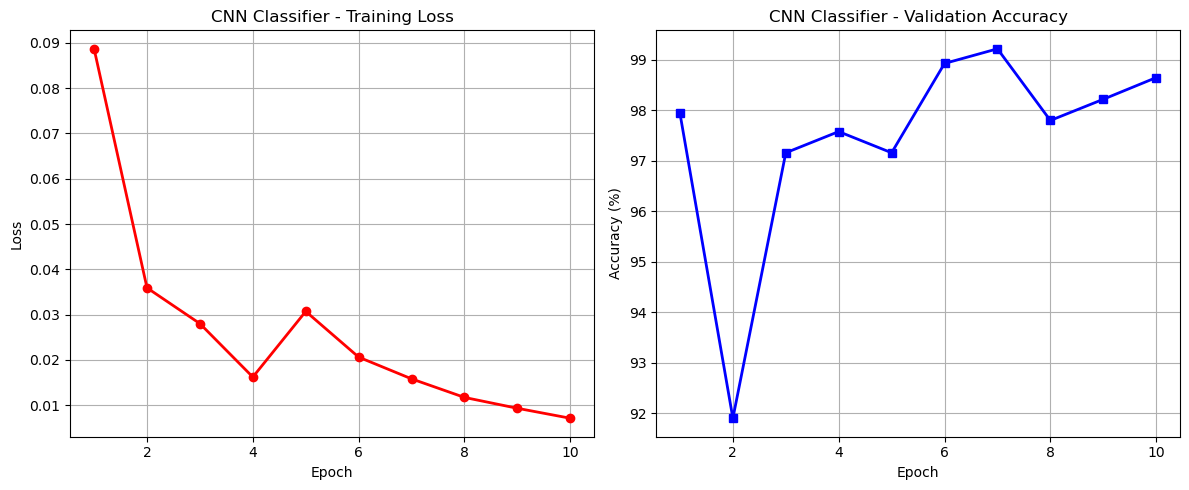

In [1]:
import matplotlib.pyplot as plt

# Data
epochs = list(range(1, 11))
loss = [0.0887, 0.0359, 0.0280, 0.0162, 0.0307, 0.0206, 0.0158, 0.0117, 0.0093, 0.0071]
val_acc = [97.94, 91.90, 97.16, 97.58, 97.16, 98.93, 99.22, 97.80, 98.22, 98.65]

# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss, marker='o', color='red', linestyle='-', linewidth=2)
plt.title("CNN Classifier - Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# Plot Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, val_acc, marker='s', color='blue', linestyle='-', linewidth=2)
plt.title("CNN Classifier - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

## live checking classifier


In [3]:
import cv2
import torch
import torchvision.transforms as transforms
import torchvision.models as models

# 1. Recreate the same ResNet18 architecture
model = models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 2)  # 2 classes

# 2. Load your trained weights
model.load_state_dict(torch.load("drone_classifier.pth", map_location="cpu"))
model.eval()

# 3. Define preprocessing (same as training, but with ImageNet normalization)
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # matches your training script
])

# 4. Class names (must match your dataset folders)
class_names = ["non_drone", "drone"]

# 5. Open webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Preprocess frame
    img = transform(frame).unsqueeze(0)

    # Run inference
    with torch.no_grad():
        outputs = model(img)
        _, predicted = torch.max(outputs, 1)

    label = class_names[predicted.item()]
    cv2.putText(frame, f"Class: {label}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2.imshow("Drone Classifier", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

C:\Users\100ra\AppData\Local\Temp\ipykernel_32416\3852485307.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("drone_classifier.pth", ma